# Angular Distribution Sample Comparison (c0-Normalized)

This notebook compares **pre-generated ENDF samples** with EXFOR data and reference evaluations (JEFF-4.0 and JENDL-5),
showing **c0-normalized angular distributions** that scale all ENDF curves to match EXFOR experimental data.

## Normalization Approach
Instead of energy folding, we use **c0-based normalization**:
1. Fit EXFOR data with Legendre polynomials to extract c0 (isotropic component = total XS / 4π)
2. Scale all ENDF differential cross sections by the EXFOR-derived c0
3. This aligns ENDF curves with experimental data at the isotropic level

## Expected Directory Structure for Samples
```
<SAMPLES_BASE_DIR>/
  endf/
    average/
      26-Fe-56g_average.endf  (or similar)
    nominal/
      26-Fe-56g_nominal.endf  (or similar)
    0001/
      26-Fe-56g_0001.endf
    0002/
      26-Fe-56g_0002.endf
    ...
```


## 1. Configuration Parameters

In [1]:
# ============================================================================
# USER CONFIGURABLE PARAMETERS
# ============================================================================

# Path to directory containing pre-generated ENDF samples
# Expected structure: <base_dir>/endf/NNNN/26-Fe-56g_NNNN.endf
# Special directories: evaluation/, nominal/ for reference files
SAMPLES_BASE_DIR = '/share_snc/snc/JuanMonleon/ENDF_samples/'
# "/mnt/c/Users/MONLEON-DE-LA-JAN/Documents/endf_files"
#'/share_snc/snc/JuanMonleon/ENDF_samples'

# Reference evaluations for comparison
JEFF_FILE = "/mnt/c/Users/MONLEON-DE-LA-JAN/Documents/endf_files/26-Fe-56g.txt"
JENDL_FILE = "/mnt/c/Users/MONLEON-DE-LA-JAN/Documents/endf_files/260560.jendl5"

# TALYS calculation directory
TALYS_BASE_DIR = "/home/MONLEON-JUAN/kika/myworkspace/TALYS"
TALYS_ENERGY_TOLERANCE_MEV = 0.05  # Max distance to match a TALYS energy directory

# EXFOR configuration (same as reference notebook)
EXFOR_DB_PATH = '/share_snc/snc/JuanMonleon/EXFOR/x4_iron_angular.db'
TARGET_ZAIDS = [26056, 26000]  # Fe-56 + natural iron
MT_NUMBER = 2  # Elastic scattering

# Supplementary JSON files (experiments not in database)
SUPPLEMENTARY_JSON_FILES = [
    '/share_snc/snc/JuanMonleon/EXFOR/data_v1/27673002.json',  # Gkatis (2025)
]

# Experiment exclusion
EXCLUDE_EXPERIMENTS = ["32246002"]

# - "20743002" - Cierjacks (1978)
# - "32246002" - Tostkii (1957)

# Minimum relative uncertainty floor
MIN_RELATIVE_UNCERTAINTY = 0.03  # 3% minimum uncertainty floor

# Target masses for LAB->CM conversion
M_PROJ_U = 1.008665  # Neutron mass (u)
M_TARG_U = 55.93494  # Fe-56 mass (u)

# TOF parameters for energy bin computation
DELTA_T_NS = 5.0      # Time resolution (ns)
FLIGHT_PATH_M = 27.037  # Flight path (m)

# ============================================================================
# PLOT VISIBILITY TOGGLES
# ============================================================================
SHOW_SAMPLES = True       # MC sample curves (gray lines)
SHOW_JEFF = True          # JEFF-4.0 evaluation (blue dashed)
SHOW_JENDL = True         # JENDL-5 evaluation (green dashed)
SHOW_AVERAGE = False       # Average/evaluation curve (blue solid)
SHOW_NOMINAL = True       # Nominal curve (red solid = "This work")
SHOW_TALYS_BASE = True    # TALYS base calculation (darkorange dashed)
SHOW_TALYS_JLM = True     # TALYS jlm_0_yes calculation (purple dashed)

# ============================================================================
# EXTENDED EXFOR PLOTTING
# ============================================================================
EXFOR_PLOT_N_SIGMA = 2.0       # How many sigma_E to extend for plotting (0 = disabled)
EXFOR_PLOT_MIN_ALPHA = 0.3     # Minimum alpha for most distant nearby points

# ============================================================================
# c0-NORMALIZATION APPROACH
# ============================================================================
# We fit EXFOR data with Legendre polynomials: y(μ) = Σ c_l P_l(μ)
# The c0 coefficient represents the isotropic component = σ_total / (4π)
# All ENDF curves are normalized by this c0 to align with experimental data.
# ============================================================================

# ============================================================================
# FIGURE EXPORT SETTINGS
# ============================================================================
SAVE_FIGURES = True
FIGURES_DIR = '/share_snc/snc/JuanMonleon/DA_Figures/samples'
FIGURE_FORMAT = 'png'
FIGURE_DPI = 300

import os
os.makedirs(FIGURES_DIR, exist_ok=True)

# ============================================================================
# DISPLAY PARAMETERS
# ============================================================================
print(f"Configuration:")
print(f"  Samples directory: {SAMPLES_BASE_DIR}")
print(f"  JEFF evaluation: {JEFF_FILE}")

Configuration:
  Samples directory: /share_snc/snc/JuanMonleon/ENDF_samples/
  JEFF evaluation: /mnt/c/Users/MONLEON-DE-LA-JAN/Documents/endf_files/26-Fe-56g.txt


## 2. Imports and Setup

In [2]:
import sys
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add kika to path if needed
_kika_path = Path().absolute().parent.parent.parent.parent
if str(_kika_path) not in sys.path:
    sys.path.insert(0, str(_kika_path))

# Import kika modules
import kika
from kika.endf import read_endf
import kika.exfor as exfor
from kika.exfor import read_all_exfor

# Import angular distribution function (for computing f(μ) from ENDF coefficients)
from kika.utils.energy_folding import endf_angular_distribution

# Import scripts modules
from scripts.exfor_utils import (
    build_exfor_cache_from_objects,
    filter_exfor_with_energy_bin,
    filter_exfor_with_kernel_weights,
    EnergyBinInfo,
)
from scripts.resample_AD import (
    compute_energy_resolution_tof as compute_sigma_E,
    sample_legendre_coefficients,
)

# Configure EXFOR database
exfor.configure(db_path=EXFOR_DB_PATH)

print("Imports successful!")

Imports successful!


## 3. Load All Data (Run Once)

Loads all ENDF files (samples, JEFF, JENDL) and EXFOR data, caching the full
energy grids and Legendre coefficient lists. This section only needs to run
once per session.

In [19]:
# Scan for all sample files
sample_pattern = f"{SAMPLES_BASE_DIR}/without/*/26-Fe-56g*.endf"
all_sample_files = sorted(glob.glob(sample_pattern))

print(f"Looking for samples with pattern: {sample_pattern}")
print(f"Found {len(all_sample_files)} total files")

# Separate special files from numbered samples
evaluation_file = None
nominal_file = None
numbered_sample_files = []

for f in all_sample_files:
    parent_dir = Path(f).parent.name
    if parent_dir == "average":
        evaluation_file = f
        print(f"  Found average file: {f}")
    elif parent_dir == "nominal":
        nominal_file = f
        print(f"  Found nominal file: {f}")
    elif parent_dir.isdigit() and len(parent_dir) == 4:
        numbered_sample_files.append(f)

print(f"\nNumbered MC samples: {len(numbered_sample_files)}")
if len(numbered_sample_files) > 0:
    print(f"First few: {[Path(f).parent.name for f in numbered_sample_files[:3]]}")
    
if len(numbered_sample_files) == 0 and evaluation_file is None and nominal_file is None:
    print("\nWARNING: No sample files found!")
    print("Please check SAMPLES_BASE_DIR and ensure the directory structure is:")
    print("  <base_dir>/endf/NNNN/26-Fe-56g_NNNN.endf")
    print("  <base_dir>/endf/average/26-Fe-56g_average.endf (optional)")
    print("  <base_dir>/endf/nominal/26-Fe-56g_nominal.endf (optional)")

Looking for samples with pattern: /share_snc/snc/JuanMonleon/ENDF_samples//without/*/26-Fe-56g*.endf
Found 26 total files
  Found nominal file: /share_snc/snc/JuanMonleon/ENDF_samples//without/nominal/26-Fe-56g_nominal.endf

Numbered MC samples: 25
First few: ['0001', '0002', '0003']


In [20]:
# ============================================================================
# Load ALL sample ENDF files and cache full Legendre coefficient data
# ============================================================================
# Coefficients at a specific target energy are extracted in Section B below.

first_file = evaluation_file or nominal_file or (numbered_sample_files[0] if numbered_sample_files else None)

# --- Energy grid from first file ---
if first_file:
    print(f"Reading first sample to determine energy grid: {Path(first_file).name}")
    _first = read_endf(first_file, mf_numbers=4)
    _mt = _first.files[4].sections[MT_NUMBER]
    sample_energies_ev = np.array(_mt.legendre_energies)
    sample_energies_mev = sample_energies_ev / 1e6
    print(f"  Energy grid: {len(sample_energies_mev)} points, "
          f"[{sample_energies_mev.min():.4f}, {sample_energies_mev.max():.4f}] MeV")
else:
    sample_energies_ev = sample_energies_mev = None
    print("No sample files to analyze.")

# --- Evaluation (average) file ---
cached_eval_coeffs_list = None
if evaluation_file:
    print(f"Loading average file: {Path(evaluation_file).name}")
    _endf_eval = read_endf(evaluation_file, mf_numbers=4)
    cached_eval_coeffs_list = _endf_eval.files[4].sections[MT_NUMBER].legendre_coefficients
    print(f"  Cached {len(cached_eval_coeffs_list)} energy points")

# --- Nominal file ---
cached_nom_coeffs_list = None
if nominal_file:
    print(f"Loading nominal file: {Path(nominal_file).name}")
    _endf_nom = read_endf(nominal_file, mf_numbers=4)
    cached_nom_coeffs_list = _endf_nom.files[4].sections[MT_NUMBER].legendre_coefficients
    print(f"  Cached {len(cached_nom_coeffs_list)} energy points")

# --- All numbered samples ---
cached_sample_coeffs_lists = []
if len(numbered_sample_files) > 0:
    print(f"Loading {len(numbered_sample_files)} numbered sample files...")
    for i, filepath in enumerate(numbered_sample_files):
        _endf = read_endf(filepath, mf_numbers=4)
        cached_sample_coeffs_lists.append(
            _endf.files[4].sections[MT_NUMBER].legendre_coefficients
        )
        if (i + 1) % 100 == 0 or i == len(numbered_sample_files) - 1:
            print(f"  Loaded {i + 1}/{len(numbered_sample_files)} samples")
    print(f"Cached {len(cached_sample_coeffs_lists)} sample files")
else:
    print("No numbered samples to load.")

Reading first sample to determine energy grid: 26-Fe-56g_nominal.endf
  Energy grid: 3960 points, [0.0000, 45.0000] MeV
Loading nominal file: 26-Fe-56g_nominal.endf
  Cached 3960 energy points
Loading 25 numbered sample files...
  Loaded 25/25 samples
Cached 25 sample files


## 3b. TALYS Helper Functions

In [5]:
import os

def lab_to_cm_angle(theta_lab_deg, m_proj_u, m_targ_u):
    """
    Convert scattering angle from LAB frame to CM frame.

    Parameters
    ----------
    theta_lab_deg : array-like
        Scattering angle in LAB frame (degrees)
    m_proj_u : float
        Projectile mass (atomic mass units)
    m_targ_u : float
        Target mass (atomic mass units)

    Returns
    -------
    theta_cm_deg : array-like
        Scattering angle in CM frame (degrees)
    """
    theta_lab_rad = np.radians(theta_lab_deg)
    A = m_targ_u / m_proj_u  # Mass ratio

    # CM angle formula: tan(θ_CM) = sin(θ_LAB) / (cos(θ_LAB) + 1/A)
    theta_cm_rad = np.arctan2(
        np.sin(theta_lab_rad),
        np.cos(theta_lab_rad) + 1.0 / A
    )

    return np.degrees(theta_cm_rad)

def load_talys_l00(filepath, m_proj_u=None, m_targ_u=None):
    """
    Load a TALYS .L00 file and return angle (cos_theta) and xs (b/sr) arrays.

    NOTE: TALYS outputs angles in the LAB frame. If m_proj_u and m_targ_u are provided,
    the angles will be converted to the CM frame before computing mu = cos(theta).

    Parameters
    ----------
    filepath : str
        Path to the TALYS .L00 file
    m_proj_u : float, optional
        Projectile mass in atomic mass units (for LAB→CM conversion)
    m_targ_u : float, optional
        Target mass in atomic mass units (for LAB→CM conversion)

    Returns
    -------
    dict
        Dictionary with keys: 'mu' (cos θ_CM), 'xs' (b/sr), 'angles_deg' (θ_LAB in deg)
    """
    angles_deg = []
    xs_mb = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            parts = line.split()
            if len(parts) >= 2:
                angles_deg.append(float(parts[0]))
                xs_mb.append(float(parts[1]))

    angles_lab_deg = np.array(angles_deg)
    xs_mb = np.array(xs_mb)

    # Convert LAB angles to CM angles if masses are provided
    if m_proj_u is not None and m_targ_u is not None:
        angles_cm_deg = lab_to_cm_angle(angles_lab_deg, m_proj_u, m_targ_u)
        mu = np.cos(np.radians(angles_cm_deg))
    else:
        # No conversion - assume angles are already in CM frame
        mu = np.cos(np.radians(angles_lab_deg))

    xs_b = xs_mb / 1000.0  # mb/sr -> b/sr
    return {'mu': mu, 'xs': xs_b, 'angles_deg': angles_lab_deg}

print("TALYS helper functions defined.")

TALYS helper functions defined.


## 4. Load Reference Evaluations (Run Once)

Read JEFF and JENDL evaluation files and cache their full energy grids and
Legendre coefficient lists.

In [6]:
# Load JEFF evaluation (full data cached)
print(f"Reading JEFF evaluation: {JEFF_FILE}")
endf_jeff = read_endf(JEFF_FILE)
mf4_jeff = endf_jeff.get_file(4)
mt_jeff = mf4_jeff.sections.get(MT_NUMBER)
jeff_energies_ev = np.array(mt_jeff.legendre_energies)
jeff_energies_mev = jeff_energies_ev / 1e6
jeff_all_coeffs = mt_jeff.legendre_coefficients
print(f"  Energy grid: {len(jeff_energies_mev)} points, "
      f"[{jeff_energies_mev.min():.4f}, {jeff_energies_mev.max():.4f}] MeV")

# Load JENDL evaluation (full data cached)
print(f"\nReading JENDL evaluation: {JENDL_FILE}")
endf_jendl = read_endf(JENDL_FILE)
mf4_jendl = endf_jendl.get_file(4)
mt_jendl = mf4_jendl.sections.get(MT_NUMBER)
jendl_energies_ev = np.array(mt_jendl.legendre_energies)
jendl_energies_mev = jendl_energies_ev / 1e6
jendl_all_coeffs = mt_jendl.legendre_coefficients
print(f"  Energy grid: {len(jendl_energies_mev)} points, "
      f"[{jendl_energies_mev.min():.4f}, {jendl_energies_mev.max():.4f}] MeV")

Reading JEFF evaluation: /mnt/c/Users/MONLEON-DE-LA-JAN/Documents/endf_files/26-Fe-56g.txt


/home/MONLEON-JUAN/kika/kika/endf/parsers/parse_endf.py:94: UserWarning: Skipping MF sections without parsers: [6, 8, 10, 12, 14, 33]. Only parsing: [1, 2, 3, 4, 34]
  warnings.warn(f"Skipping MF sections without parsers: {skipped_mfs}. Only parsing: {parseable_mfs}")


  Energy grid: 3960 points, [0.0000, 45.0000] MeV

Reading JENDL evaluation: /mnt/c/Users/MONLEON-DE-LA-JAN/Documents/endf_files/260560.jendl5


/home/MONLEON-JUAN/kika/kika/endf/parsers/parse_endf.py:94: UserWarning: Skipping MF sections without parsers: [6, 8, 33]. Only parsing: [1, 2, 3, 4, 34]
  warnings.warn(f"Skipping MF sections without parsers: {skipped_mfs}. Only parsing: {parseable_mfs}")


  Energy grid: 1796 points, [0.0000, 20.0000] MeV


## 5. Load and Filter EXFOR Data (Run Once)

Load EXFOR data from the database and build the cache. This only loads
the raw data — energy-dependent filtering happens in Section B.

In [7]:
print("Loading EXFOR data from database...")

# Load EXFOR data
exfor_dict = read_all_exfor(
    target=TARGET_ZAIDS,
    mt=MT_NUMBER,
    source="database",
    group_by_energy=False,
    supplementary_json_files=SUPPLEMENTARY_JSON_FILES,
    exclude_experiments=EXCLUDE_EXPERIMENTS,
)

# Convert to cache format
exfor_objects = list(exfor_dict.values())
exfor_cache, sorted_exfor_energies = build_exfor_cache_from_objects(
    exfor_objects, 
    exclude_experiments=EXCLUDE_EXPERIMENTS,
)

print(f"Loaded {len(exfor_objects)} EXFOR datasets")
print(f"Unique energies: {len(sorted_exfor_energies)}")
print(f"Energy range: [{min(sorted_exfor_energies):.4f}, {max(sorted_exfor_energies):.4f}] MeV")
if EXCLUDE_EXPERIMENTS:
    print(f"Excluded experiments: {EXCLUDE_EXPERIMENTS}")

Loading EXFOR data from database...
Loaded 119 EXFOR datasets
Unique energies: 22687
Energy range: [0.0350, 96.0000] MeV
Excluded experiments: ['32246002']


## 6. Multi-Energy Processing

Process multiple target energies and collect results for multi-panel plotting.

In [8]:
from dataclasses import dataclass, field
from typing import Optional, Dict, List, Tuple

@dataclass
class EnergyResult:
    """All results for a single target energy."""
    energy_mev: float
    closest_energy_mev: float
    bin_info: 'EnergyBinInfo'
    sigma_E_mev: float

    # Coefficients at this energy
    evaluation_coeffs: Optional[np.ndarray]
    nominal_coeffs: Optional[np.ndarray]
    sample_coeffs_array: Optional[np.ndarray]
    jeff_coeffs: np.ndarray
    jendl_coeffs: np.ndarray

    # TALYS data
    talys_base_data: Optional[dict]
    talys_jlm_data: Optional[dict]

    # EXFOR fit data (used for c0 Legendre fit) — these get COLORED in plots
    exfor_df: pd.DataFrame
    experiments_info: list
    kernel_weights: np.ndarray

    # Extended EXFOR data (for plot context) — these are GRAY in plots
    ext_df: pd.DataFrame
    exp_label_map: dict

    # Fit results
    c0_exfor: float
    fit_info: dict
    fit_degree: int

    # Computed dσ/dΩ curves
    mu_grid: np.ndarray
    dsigma_nominal: Optional[np.ndarray]
    dsigma_evaluation: Optional[np.ndarray]
    dsigma_jeff: np.ndarray
    dsigma_jendl: np.ndarray
    sample_dsigma_array: Optional[np.ndarray]


def compute_normalized_dsigma(endf_coeffs, c0_norm, mu_grid):
    """
    Compute dσ/dΩ from ENDF coefficients, normalized by c0.

    dσ/dΩ = 2 × c0 × f(μ), where f(μ) is the ENDF angular PDF.
    For isotropic scattering (f=0.5), dσ/dΩ = c0.
    """
    angular_pdf = endf_angular_distribution(mu_grid, endf_coeffs)
    return 2.0 * c0_norm * angular_pdf


print("EnergyResult and compute_normalized_dsigma defined.")

EnergyResult and compute_normalized_dsigma defined.


## 7. Per-Energy Processing Function

Encapsulates the full pipeline for a single energy: coefficient extraction, EXFOR filtering, Legendre fitting, and dσ/dΩ computation.

In [9]:
def process_energy(
    target_energy_mev,
    # Cached sample data
    sample_energies_mev, cached_eval_coeffs_list, cached_nom_coeffs_list,
    cached_sample_coeffs_lists,
    # Cached JEFF/JENDL data
    jeff_energies_mev, jeff_energies_ev, jeff_all_coeffs,
    jendl_energies_mev, jendl_all_coeffs,
    # EXFOR data
    exfor_cache, sorted_exfor_energies,
    # TALYS
    talys_base_dir, talys_energy_tolerance_mev,
    # Config
    delta_t_ns, flight_path_m,
    m_proj_u, m_targ_u,
    exclude_experiments, min_relative_uncertainty,
    exfor_plot_n_sigma, exfor_plot_min_alpha,
    # Optional
    verbose=True,
):
    """Process a single energy: extract coefficients, filter EXFOR, fit, compute curves."""

    # --- Extract sample coefficients at target energy ---
    if sample_energies_mev is not None:
        target_idx = np.argmin(np.abs(sample_energies_mev - target_energy_mev))
        closest_energy_mev = sample_energies_mev[target_idx]
    else:
        closest_energy_mev = target_energy_mev
        target_idx = 0

    evaluation_coeffs = None
    evaluation_degree = None
    if cached_eval_coeffs_list is not None:
        evaluation_coeffs = np.array(cached_eval_coeffs_list[target_idx])
        evaluation_degree = len(evaluation_coeffs)

    nominal_coeffs = None
    if cached_nom_coeffs_list is not None:
        nominal_coeffs = np.array(cached_nom_coeffs_list[target_idx])

    sample_coeffs_array = None
    if cached_sample_coeffs_lists:
        _coeffs = [np.array(cl[target_idx]) for cl in cached_sample_coeffs_lists]
        max_len = max(len(c) for c in _coeffs)
        sample_coeffs_array = np.zeros((len(_coeffs), max_len))
        for i, c in enumerate(_coeffs):
            sample_coeffs_array[i, :len(c)] = c

    # --- JEFF/JENDL at target energy ---
    jeff_target_idx = np.argmin(np.abs(jeff_energies_mev - target_energy_mev))
    jeff_closest_energy_mev = jeff_energies_mev[jeff_target_idx]
    jeff_coeffs = np.array(jeff_all_coeffs[jeff_target_idx])

    jendl_target_idx = np.argmin(np.abs(jendl_energies_mev - target_energy_mev))
    jendl_closest_energy_mev = jendl_energies_mev[jendl_target_idx]
    jendl_coeffs = np.array(jendl_all_coeffs[jendl_target_idx])

    # --- Load TALYS ---
    talys_base_data = None
    talys_jlm_data = None
    talys_dir = Path(talys_base_dir)

    if talys_dir.is_dir():
        available_energies = {}
        for entry in sorted(talys_dir.iterdir()):
            if entry.is_dir():
                try:
                    available_energies[entry.name] = float(entry.name)
                except ValueError:
                    pass

        if available_energies:
            e_vals = np.array(list(available_energies.values()))
            e_names = list(available_energies.keys())
            closest_talys_idx = np.argmin(np.abs(e_vals - target_energy_mev))
            closest_talys_e = e_vals[closest_talys_idx]
            talys_distance = abs(closest_talys_e - target_energy_mev)

            if talys_distance <= talys_energy_tolerance_mev:
                matching_dir = e_names[closest_talys_idx]
                energy_path = talys_dir / matching_dir

                base_path = energy_path / 'base'
                if base_path.is_dir():
                    l00_files = list(base_path.glob('*.L00'))
                    if l00_files:
                        talys_base_data = load_talys_l00(str(l00_files[0]), m_proj_u, m_targ_u)

                jlm_path = energy_path / 'jlm_0_yes'
                if jlm_path.is_dir():
                    l00_files = list(jlm_path.glob('*.L00'))
                    if l00_files:
                        talys_jlm_data = load_talys_l00(str(l00_files[0]), m_proj_u, m_targ_u)

    # --- Energy bin ---
    sigma_E_mev = compute_sigma_E(
        E_mev=closest_energy_mev,
        delta_t_ns=delta_t_ns,
        flight_path_m=flight_path_m,
    )

    if jeff_target_idx > 0:
        bin_lower = (jeff_energies_mev[jeff_target_idx - 1] + jeff_closest_energy_mev) / 2
    else:
        bin_lower = 0.0
    if jeff_target_idx < len(jeff_energies_mev) - 1:
        bin_upper = (jeff_closest_energy_mev + jeff_energies_mev[jeff_target_idx + 1]) / 2
    else:
        bin_upper = float('inf')

    bin_info = EnergyBinInfo(
        index=jeff_target_idx,
        energy_ev=jeff_energies_ev[jeff_target_idx],
        energy_mev=jeff_closest_energy_mev,
        sigma_E_mev=sigma_E_mev,
        bin_lower_mev=bin_lower,
        bin_upper_mev=bin_upper,
    )

    # --- Filter EXFOR for fit ---
    exfor_df, experiments_info, kernel_weights, diagnostics = filter_exfor_with_energy_bin(
        exfor_cache=exfor_cache,
        sorted_energies=sorted_exfor_energies,
        bin_lower_mev=bin_info.bin_lower_mev,
        bin_upper_mev=bin_info.bin_upper_mev,
        target_energy_mev=bin_info.energy_mev,
        m_proj_u=m_proj_u,
        m_targ_u=m_targ_u,
        dedupe_per_experiment=True,
        exclude_experiments=exclude_experiments,
        min_relative_uncertainty=min_relative_uncertainty,
        normalize_by_n_points=True,
        max_experiment_weight_fraction=0.5,
    )
    if not exfor_df.empty and 'experiment_id' not in exfor_df.columns:
        exfor_df['experiment_id'] = exfor_df['entry'] + '/' + exfor_df['subentry']

    # --- Extended EXFOR for plot context ---
    ext_df = pd.DataFrame()
    exp_label_map = {}

    if exfor_plot_n_sigma > 0:
        ext_df, ext_experiments_info, ext_kw, ext_diag = filter_exfor_with_kernel_weights(
            exfor_cache=exfor_cache,
            sorted_energies=sorted_exfor_energies,
            energy_mev=bin_info.energy_mev,
            sigma_E_mev=sigma_E_mev,
            n_sigma=exfor_plot_n_sigma,
            m_proj_u=m_proj_u,
            m_targ_u=m_targ_u,
            bin_lower_mev=bin_info.bin_lower_mev,
            bin_upper_mev=bin_info.bin_upper_mev,
            use_overlap_weights=False,
            dedupe_per_experiment=False,
            normalize_by_n_points=False,
            exclude_experiments=exclude_experiments,
            min_relative_uncertainty=min_relative_uncertainty,
            max_experiment_weight_fraction=1.0,
        )

        if not ext_df.empty:
            if 'experiment_id' not in ext_df.columns:
                ext_df['experiment_id'] = ext_df['entry'] + '/' + ext_df['subentry']

            # Compute plot_alpha from kernel weights
            max_kw = ext_kw.max() if len(ext_kw) > 0 else 1.0
            norm_kw = ext_kw / max_kw if max_kw > 0 else np.ones_like(ext_kw)
            ext_df['plot_alpha'] = exfor_plot_min_alpha + norm_kw * (0.9 - exfor_plot_min_alpha)

            # Build label map
            for info in ext_experiments_info:
                eid = f"{info.get('entry', '')}/{info.get('subentry', '')}"
                author = info.get('author', eid)
                year = info.get('year', '?')
                exp_label_map[eid] = f"{author} ({year})"

    # Also add labels from fit experiments
    for info in experiments_info:
        eid = f"{info.get('entry', '')}/{info.get('subentry', '')}"
        author = info.get('author', eid)
        year = info.get('year', '?')
        exp_label_map[eid] = f"{author} ({year})"

    # --- Legendre fit for c0 ---
    if evaluation_degree is not None:
        fit_degree = evaluation_degree
    else:
        fit_degree = len(jeff_coeffs)

    coef_df, fit_info = sample_legendre_coefficients(
        df=exfor_df,
        value_col="value",
        unc_col="unc",
        mu_col="mu",
        degree=fit_degree,
        ridge_lambda=1e-6,
        n_samples=1,
        rescale_unc_by_chi2=True,
        external_weights=kernel_weights,
    )
    c0_exfor = coef_df['c0'].values[0]

    # --- Compute dσ/dΩ ---
    mu_grid = np.linspace(-1, 1, 200)

    dsigma_evaluation = None
    if evaluation_coeffs is not None:
        dsigma_evaluation = compute_normalized_dsigma(evaluation_coeffs, c0_exfor, mu_grid)

    dsigma_nominal = None
    if nominal_coeffs is not None:
        dsigma_nominal = compute_normalized_dsigma(nominal_coeffs, c0_exfor, mu_grid)

    dsigma_jeff = compute_normalized_dsigma(jeff_coeffs, c0_exfor, mu_grid)
    dsigma_jendl = compute_normalized_dsigma(jendl_coeffs, c0_exfor, mu_grid)

    sample_dsigma_array = None
    if sample_coeffs_array is not None and len(sample_coeffs_array) > 0:
        sample_dsigma_list = []
        for sc in sample_coeffs_array:
            sample_dsigma_list.append(compute_normalized_dsigma(sc, c0_exfor, mu_grid))
        sample_dsigma_array = np.array(sample_dsigma_list)

    if verbose:
        print(f"  E = {target_energy_mev:.2f} MeV -> grid {closest_energy_mev:.4f} MeV, "
              f"c0 = {c0_exfor:.4f} b/sr, chi2_red = {fit_info['chi2_red']:.2f}, "
              f"EXFOR fit pts = {len(exfor_df)}, ext pts = {len(ext_df)}")

    return EnergyResult(
        energy_mev=target_energy_mev,
        closest_energy_mev=closest_energy_mev,
        bin_info=bin_info,
        sigma_E_mev=sigma_E_mev,
        evaluation_coeffs=evaluation_coeffs,
        nominal_coeffs=nominal_coeffs,
        sample_coeffs_array=sample_coeffs_array,
        jeff_coeffs=jeff_coeffs,
        jendl_coeffs=jendl_coeffs,
        talys_base_data=talys_base_data,
        talys_jlm_data=talys_jlm_data,
        exfor_df=exfor_df,
        experiments_info=experiments_info,
        kernel_weights=kernel_weights,
        ext_df=ext_df,
        exp_label_map=exp_label_map,
        c0_exfor=c0_exfor,
        fit_info=fit_info,
        fit_degree=fit_degree,
        mu_grid=mu_grid,
        dsigma_nominal=dsigma_nominal,
        dsigma_evaluation=dsigma_evaluation,
        dsigma_jeff=dsigma_jeff,
        dsigma_jendl=dsigma_jendl,
        sample_dsigma_array=sample_dsigma_array,
    )


print("process_energy() defined.")

process_energy() defined.


## 8. Configure Target Energies and Figure Settings

In [21]:
# ============================================================================
# TARGET ENERGIES — list of energies for multi-panel figures
# ============================================================================
TARGET_ENERGIES_MEV = [1.00, 1.40, 2.15, 2.85]

# ============================================================================
# FIGURE SIZE PRESETS (width x height in inches)
# ============================================================================
FIGSIZE_2COL = (6.5, 5.5)    # Full-page width 2x2 (2-column LaTeX)
FIGSIZE_1COL = (3.25, 5.5)   # Half-page width Nx1 vertical stack (1-column LaTeX)

FONTSIZES_2COL = {'axes_label': 9, 'tick_label': 8, 'legend': 8, 'subplot_title': 9}
FONTSIZES_1COL = {'axes_label': 7, 'tick_label': 6, 'legend': 5.5, 'subplot_title': 7}

SHOW_DIAGNOSTICS = False
ALSO_GENERATE_SINGLE_PANELS = False

## 9. Process All Energies

In [22]:
# Process all target energies
energy_results = {}
for e_mev in TARGET_ENERGIES_MEV:
    result = process_energy(
        target_energy_mev=e_mev,
        sample_energies_mev=sample_energies_mev,
        cached_eval_coeffs_list=cached_eval_coeffs_list,
        cached_nom_coeffs_list=cached_nom_coeffs_list,
        cached_sample_coeffs_lists=cached_sample_coeffs_lists,
        jeff_energies_mev=jeff_energies_mev,
        jeff_energies_ev=jeff_energies_ev,
        jeff_all_coeffs=jeff_all_coeffs,
        jendl_energies_mev=jendl_energies_mev,
        jendl_all_coeffs=jendl_all_coeffs,
        exfor_cache=exfor_cache,
        sorted_exfor_energies=sorted_exfor_energies,
        talys_base_dir=TALYS_BASE_DIR,
        talys_energy_tolerance_mev=TALYS_ENERGY_TOLERANCE_MEV,
        delta_t_ns=DELTA_T_NS,
        flight_path_m=FLIGHT_PATH_M,
        m_proj_u=M_PROJ_U,
        m_targ_u=M_TARG_U,
        exclude_experiments=EXCLUDE_EXPERIMENTS,
        min_relative_uncertainty=MIN_RELATIVE_UNCERTAINTY,
        exfor_plot_n_sigma=EXFOR_PLOT_N_SIGMA,
        exfor_plot_min_alpha=EXFOR_PLOT_MIN_ALPHA,
    )
    energy_results[e_mev] = result

print(f"\nProcessed {len(energy_results)} energies.")

  E = 1.00 MeV -> grid 1.0000 MeV, c0 = 0.1786 b/sr, chi2_red = 12.75, EXFOR fit pts = 75, ext pts = 735
  E = 1.40 MeV -> grid 1.4000 MeV, c0 = 0.1768 b/sr, chi2_red = 8.72, EXFOR fit pts = 20, ext pts = 644
  E = 2.15 MeV -> grid 2.1500 MeV, c0 = 0.2054 b/sr, chi2_red = 0.11, EXFOR fit pts = 8, ext pts = 930
  E = 2.85 MeV -> grid 2.8500 MeV, c0 = 0.1945 b/sr, chi2_red = 10.24, EXFOR fit pts = 36, ext pts = 387

Processed 4 energies.


In [23]:
# ============================================================================
# Build GLOBAL experiment visual map (consistent colors across all subplots)
# ============================================================================
# Only experiments used in the Legendre c0 fit (exfor_df) get colors.
# Extended EXFOR data (ext_df) is always rendered in gray.

from kika.plotting.styles import _get_color_palette

KIKA_COLORS = _get_color_palette('light')  # 10 colorblind-friendly colors
EXFOR_MARKERS = ['o', 's', '^', 'v', 'D', 'p', 'h', '*', 'X', '<', '>']

# Collect all unique experiment IDs from fit data across all energies
all_fit_exp_ids = []
for result in energy_results.values():
    if not result.exfor_df.empty and 'experiment_id' in result.exfor_df.columns:
        for eid in result.exfor_df['experiment_id'].unique():
            if eid not in all_fit_exp_ids:
                all_fit_exp_ids.append(eid)

# Assign consistent color + marker to each experiment
global_exp_visual_map = {}
for i, eid in enumerate(all_fit_exp_ids):
    global_exp_visual_map[eid] = (
        KIKA_COLORS[i % len(KIKA_COLORS)],
        EXFOR_MARKERS[i % len(EXFOR_MARKERS)],
    )

# Merge label maps from all energies
global_exp_label_map = {}
for result in energy_results.values():
    global_exp_label_map.update(result.exp_label_map)

print(f"Global visual map: {len(global_exp_visual_map)} experiments with consistent colors")
for eid, (color, marker) in global_exp_visual_map.items():
    label = global_exp_label_map.get(eid, eid)
    print(f"  {marker} {label} -> {color}")

Global visual map: 12 experiments with consistent colors
  o Cierjacks (1978) -> #0173B2
  s Kinney (1976) -> #DE8F05
  ^ Cox (1966) -> #029E73
  v Walt (1954) -> #D55E00
  D Darden (1955) -> #CC78BC
  p Malmskog (1972) -> #CA9161
  h Jacquot (1966) -> #FBAFE4
  * Barnard (1968) -> #949494
  X Pirovano (2019) -> #ECE133
  < Pirovano (2019) -> #56B4E9
  > Smith (1980) -> #0173B2
  o G. Gkatis (2025) -> #DE8F05


## 10. Plotting Functions

In [24]:
from matplotlib.lines import Line2D

def plot_ad_comparison(
    ax, result, global_exp_visual_map, global_exp_label_map,
    *,
    yscale='log',
    fontsizes=None,
    max_samples=200,
    show_samples=SHOW_SAMPLES,
    show_jeff=SHOW_JEFF,
    show_jendl=SHOW_JENDL,
    show_nominal=SHOW_NOMINAL,
    show_average=SHOW_AVERAGE,
    show_talys_base=SHOW_TALYS_BASE,
    show_talys_jlm=SHOW_TALYS_JLM,
    exfor_plot_n_sigma=EXFOR_PLOT_N_SIGMA,
    linewidth_scale=1.0,
    markersize_scale=1.0,
):
    """
    Draw one energy panel onto ax. Returns list of (handle, label) for shared legend.

    Only EXFOR points from exfor_df (used in the c0 fit) are colored.
    All ext_df points are rendered in gray.
    """
    fs = fontsizes or FONTSIZES_2COL
    handles_labels = []
    mu = result.mu_grid
    lw = 2.0 * linewidth_scale
    ms_exfor = 6 * markersize_scale
    ms_ext = 4 * markersize_scale
    capsize_fit = 3 * markersize_scale
    capsize_ext = 2 * markersize_scale

    # Adaptive alpha for MC samples
    n_s = len(result.sample_dsigma_array) if result.sample_dsigma_array is not None else 0
    sample_alpha = 0.1 if n_s > 100 else (0.15 if n_s > 50 else 0.3)

    # 1. MC samples
    if show_samples and result.sample_dsigma_array is not None:
        for i in range(min(n_s, max_samples)):
            ax.plot(mu, result.sample_dsigma_array[i], '-', color='steelblue',
                    alpha=sample_alpha, linewidth=0.8 * linewidth_scale)
        mc_handle = Line2D([0], [0], color='steelblue', alpha=0.4, linewidth=lw)
        handles_labels.append((mc_handle, 'MC samples'))

    # 2. JEFF
    if show_jeff:
        h, = ax.plot(mu, result.dsigma_jeff, color='tab:blue', linestyle='-',
                      linewidth=lw, zorder=20)
        handles_labels.append((h, 'JEFF-4.0'))

    # 3. JENDL
    if show_jendl:
        h, = ax.plot(mu, result.dsigma_jendl, color='tab:green', linestyle='-',
                      linewidth=lw, zorder=20)
        handles_labels.append((h, 'JENDL-5'))

    # 4. Average/Evaluation
    if show_average and result.dsigma_evaluation is not None:
        h, = ax.plot(mu, result.dsigma_evaluation, color='b', linestyle='-',
                      linewidth=lw * 1.1, zorder=22)
        handles_labels.append((h, 'Average'))

    # 5. Nominal / This work
    if show_nominal and result.dsigma_nominal is not None:
        h, = ax.plot(mu, result.dsigma_nominal, color='tab:red', linestyle='-',
                      linewidth=lw * 1.1, zorder=23)
        handles_labels.append((h, 'This work'))

    # 6. TALYS base
    if show_talys_base and result.talys_base_data is not None:
        h, = ax.plot(result.talys_base_data['mu'], result.talys_base_data['xs'],
                      color='darkorange', linestyle='--', linewidth=lw, zorder=20)
        handles_labels.append((h, 'TALYS base'))

    # 7. TALYS JLM
    if show_talys_jlm and result.talys_jlm_data is not None:
        h, = ax.plot(result.talys_jlm_data['mu'], result.talys_jlm_data['xs'],
                      color='purple', linestyle='--', linewidth=lw, zorder=20)
        handles_labels.append((h, 'TALYS JLM'))

    # 8. Gray EXFOR: all ext_df points (extended/context data)
    if exfor_plot_n_sigma > 0 and not result.ext_df.empty:
        _gray_label_placed = False
        for eid in result.ext_df['experiment_id'].unique():
            mask = result.ext_df['experiment_id'] == eid
            df_exp = result.ext_df[mask]
            # Use experiment-specific marker shape if in global map, else 'o'
            marker = global_exp_visual_map.get(eid, (None, 'o'))[1]
            avg_alpha = df_exp['plot_alpha'].median() if 'plot_alpha' in df_exp.columns else 0.5
            label_gray = None
            if not _gray_label_placed:
                label_gray = f'Nearby EXFOR ({exfor_plot_n_sigma:.0f}$\\sigma_E$)'
                _gray_label_placed = True
            ax.errorbar(
                df_exp['mu'], df_exp['value'], yerr=df_exp['unc'],
                fmt=marker, color='0.55', label=label_gray,
                capsize=capsize_ext, markersize=ms_ext, alpha=avg_alpha,
                markerfacecolor='none', markeredgewidth=0.8, markeredgecolor='0.55',
                elinewidth=0.6, ecolor='0.7', zorder=5,
            )
        # Add gray handle for legend
        gray_handle = Line2D([0], [0], marker='o', color='0.55', markerfacecolor='none',
                             markeredgecolor='0.55', markersize=ms_ext, linestyle='none')
        handles_labels.append((gray_handle, f'Nearby EXFOR ({exfor_plot_n_sigma:.0f}$\\sigma_E$)'))

    # 9. Colored EXFOR: only fit data (exfor_df)
    if not result.exfor_df.empty and 'experiment_id' in result.exfor_df.columns:
        for eid in result.exfor_df['experiment_id'].unique():
            mask = result.exfor_df['experiment_id'] == eid
            df_exp = result.exfor_df[mask]
            if eid in global_exp_visual_map:
                color, marker = global_exp_visual_map[eid]
            else:
                color, marker = 'black', 'o'
            label = global_exp_label_map.get(eid, eid)
            ax.errorbar(
                df_exp['mu'], df_exp['value'], yerr=df_exp['unc'],
                fmt=marker, color=color, label=label,
                capsize=capsize_fit, markersize=ms_exfor, alpha=0.9,
                markeredgewidth=0.5, zorder=10,
            )
            handles_labels.append((
                Line2D([0], [0], marker=marker, color=color, markersize=ms_exfor,
                       linestyle='none', markeredgewidth=0.5),
                label
            ))

    # Formatting
    ax.set_xlim(-1, 1)
    if yscale == 'log':
        ax.set_yscale('log')
    ax.set_title(f'E = {result.energy_mev:.2f} MeV', fontsize=fs['subplot_title'])
    ax.tick_params(labelsize=fs['tick_label'])
    ax.grid(True, alpha=0.3)

    return handles_labels


print("plot_ad_comparison() defined.")

plot_ad_comparison() defined.


In [25]:
def create_multipanel_figure(
    energy_results, energies, global_exp_visual_map, global_exp_label_map,
    *,
    yscale='log',
    figsize=(6.5, 5.5),
    layout=None,
    fontsizes=None,
    linewidth_scale=1.0,
    markersize_scale=1.0,
    save_path=None,
    dpi=300,
):
    """Create a multi-panel figure with shared external legend.

    Parameters
    ----------
    layout : tuple (nrows, ncols), optional
        Subplot grid layout. If None, uses 2x2 for wide figures
        and Nx1 vertical stack for narrow figures.
    """
    fs = fontsizes or FONTSIZES_2COL
    n = len(energies)

    # Auto-detect layout from figure width if not specified
    if layout is None:
        if figsize[0] < 5:  # narrow = 1-column
            nrows, ncols = n, 1
        else:                # wide = 2-column
            nrows = 2 if n > 2 else 1
            ncols = 2 if n > 1 else 1
    else:
        nrows, ncols = layout

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, dpi=dpi, squeeze=False)

    # Collect handles/labels with deduplication (preserves insertion order)
    seen_labels = {}

    for idx, e_mev in enumerate(energies):
        row, col = divmod(idx, ncols)
        ax = axes[row][col]
        result = energy_results[e_mev]

        hl = plot_ad_comparison(
            ax, result, global_exp_visual_map, global_exp_label_map,
            yscale=yscale, fontsizes=fs,
            linewidth_scale=linewidth_scale,
            markersize_scale=markersize_scale,
        )
        for h, l in hl:
            if l not in seen_labels:
                seen_labels[l] = h

    # Hide unused subplots
    for idx in range(n, nrows * ncols):
        row, col = divmod(idx, ncols)
        axes[row][col].set_visible(False)

    # Axis labels only on edges
    for row in range(nrows):
        for col in range(ncols):
            ax = axes[row][col]
            if not ax.get_visible():
                continue
            if col == 0:
                ax.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)', fontsize=fs['axes_label'])
            else:
                ax.set_ylabel('')
            if row == nrows - 1 or (row == 0 and nrows == 1):
                ax.set_xlabel(r'$\cos(\theta_{\rm CM})$', fontsize=fs['axes_label'])
            else:
                ax.set_xlabel('')

    # Single shared legend below the subplots
    handles = list(seen_labels.values())
    labels = list(seen_labels.keys())
    legend_ncol = min(4, len(labels)) if figsize[0] > 5 else min(3, len(labels))

    # Reserve space: more for wide figures (legend fits in fewer rows),
    # less vertical fraction for tall narrow figures
    if ncols == 1:
        legend_bottom_frac = 0.06  # narrow/tall: legend takes smaller fraction
    else:
        legend_bottom_frac = 0.12  # wide/short: need more relative space

    fig.tight_layout(rect=[0, legend_bottom_frac, 1, 1])

    fig.legend(
        handles, labels,
        loc='upper center',
        bbox_to_anchor=(0.5, legend_bottom_frac - 0.01),
        ncol=legend_ncol,
        fontsize=fs['legend'],
        frameon=True,
        fancybox=True,
    )

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f'Saved: {save_path}')

    return fig


print("create_multipanel_figure() defined.")

create_multipanel_figure() defined.


## 11. Generate Multi-Panel Figures

Generate 4 variants: (log, linear) × (2-column, 1-column).


--- log scale, 2col ---
Saved: /share_snc/snc/JuanMonleon/DA_Figures/samples/samples_multipanel_1.00_1.40_2.15_2.85_log_2col.png


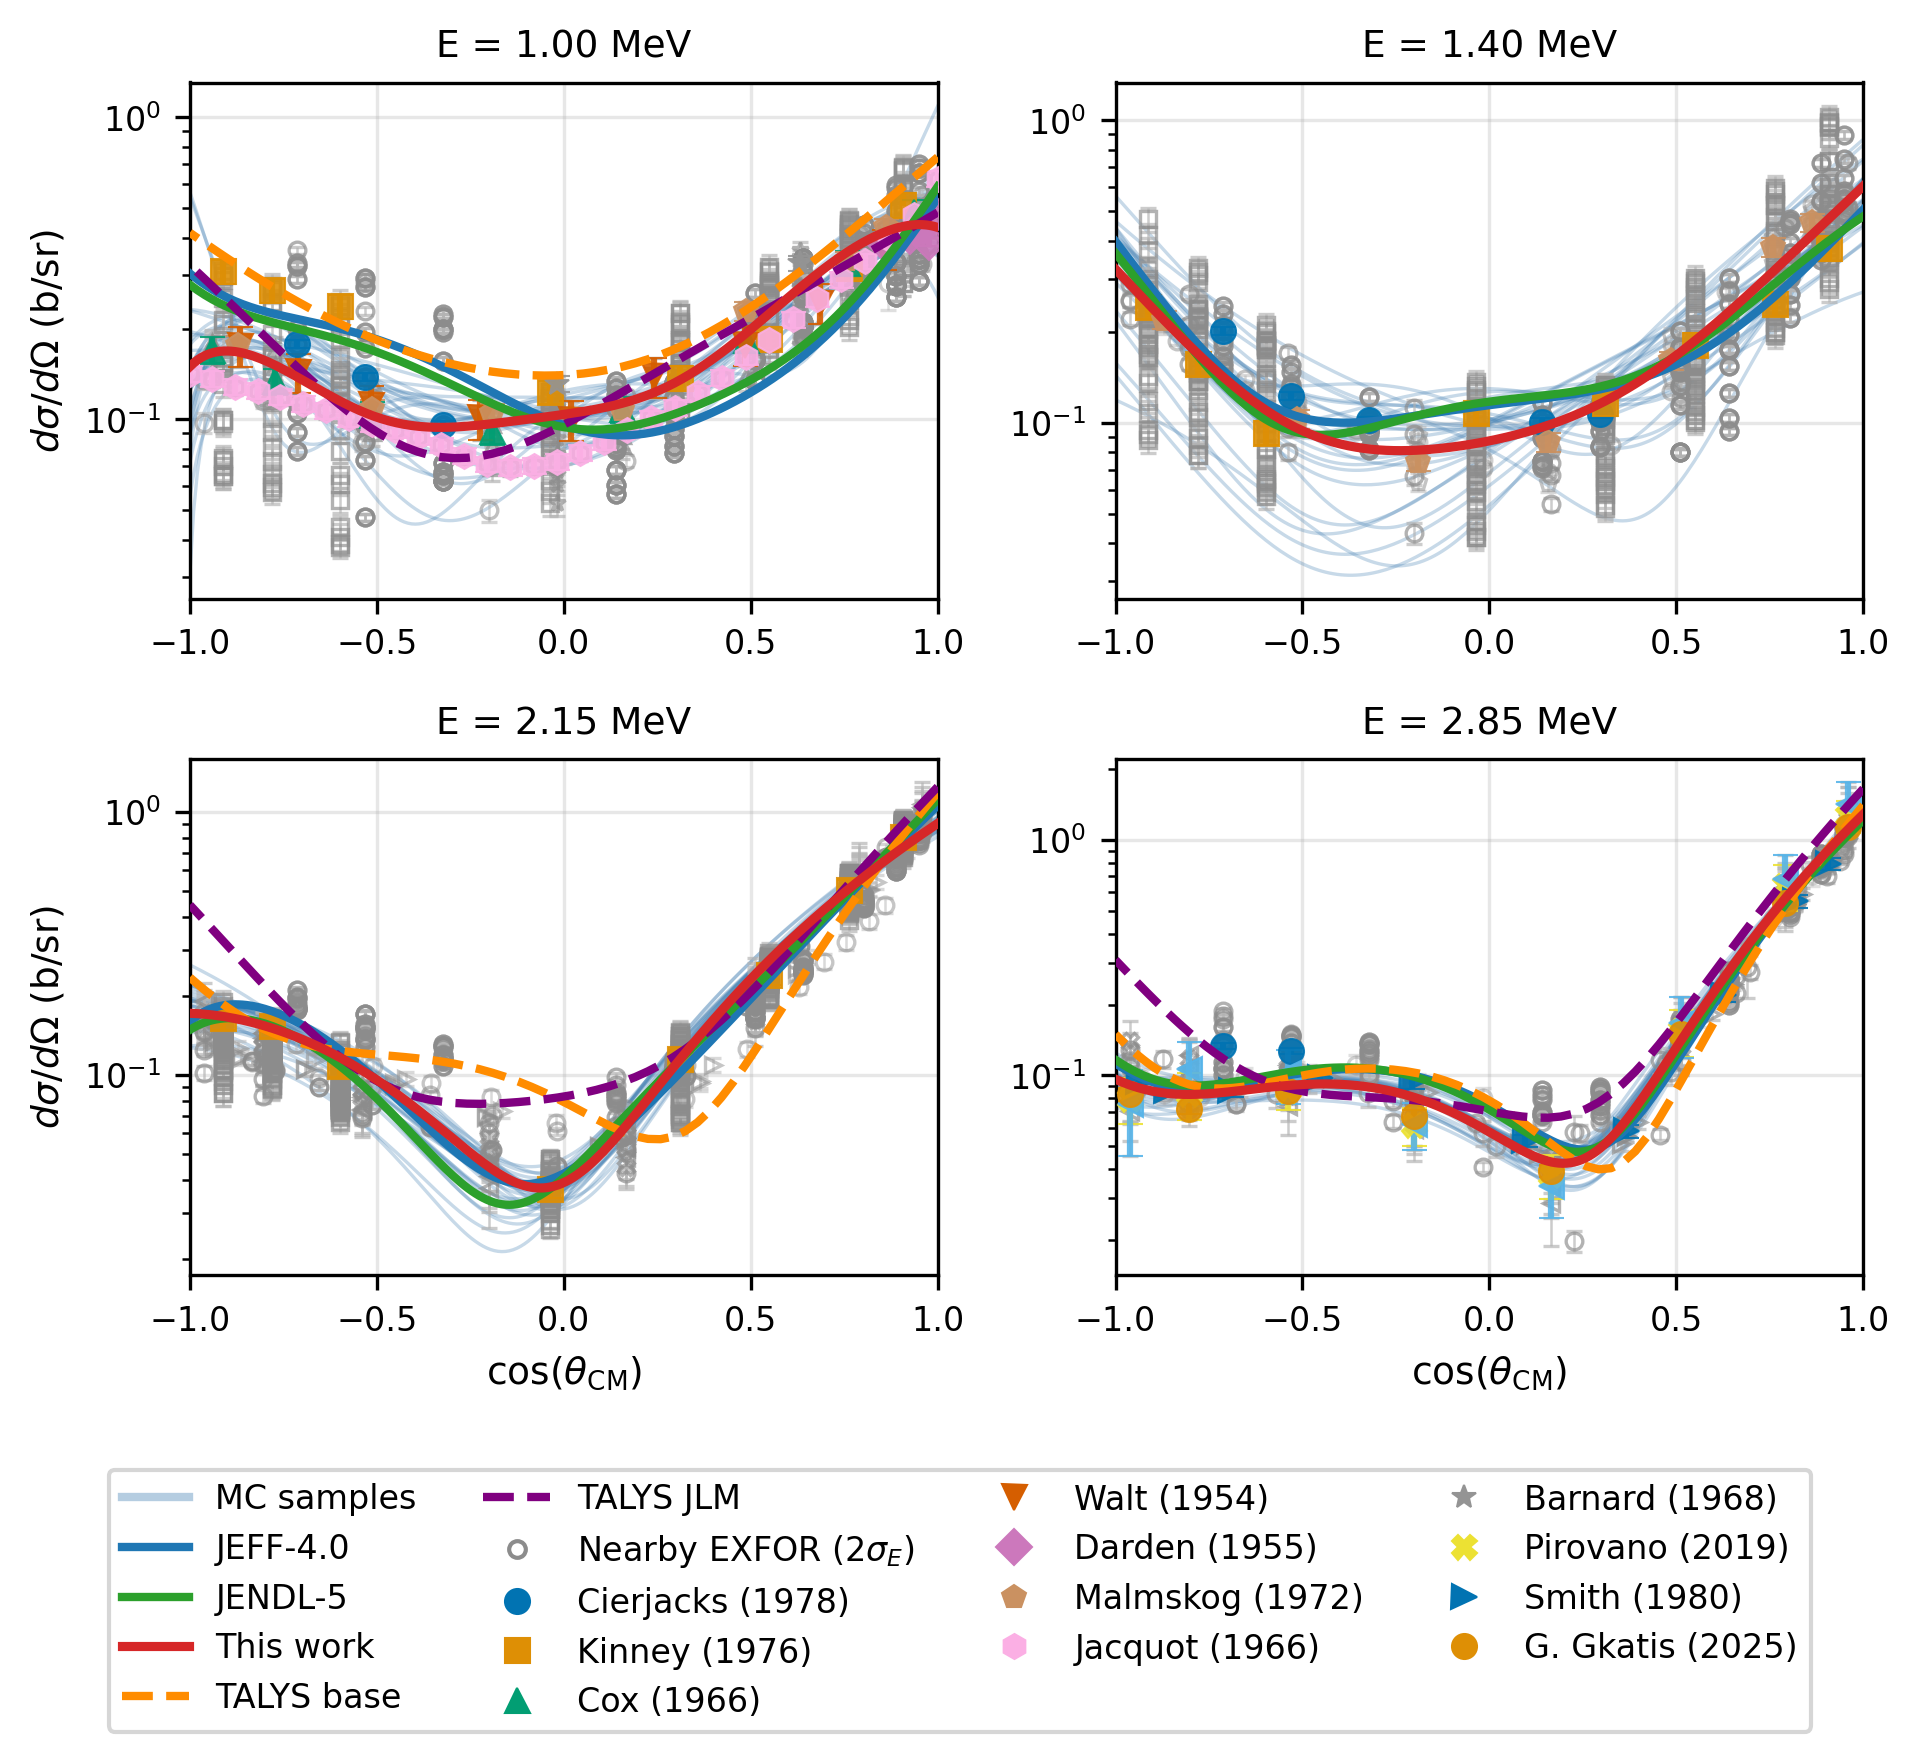


--- log scale, 1col ---
Saved: /share_snc/snc/JuanMonleon/DA_Figures/samples/samples_multipanel_1.00_1.40_2.15_2.85_log_1col.png


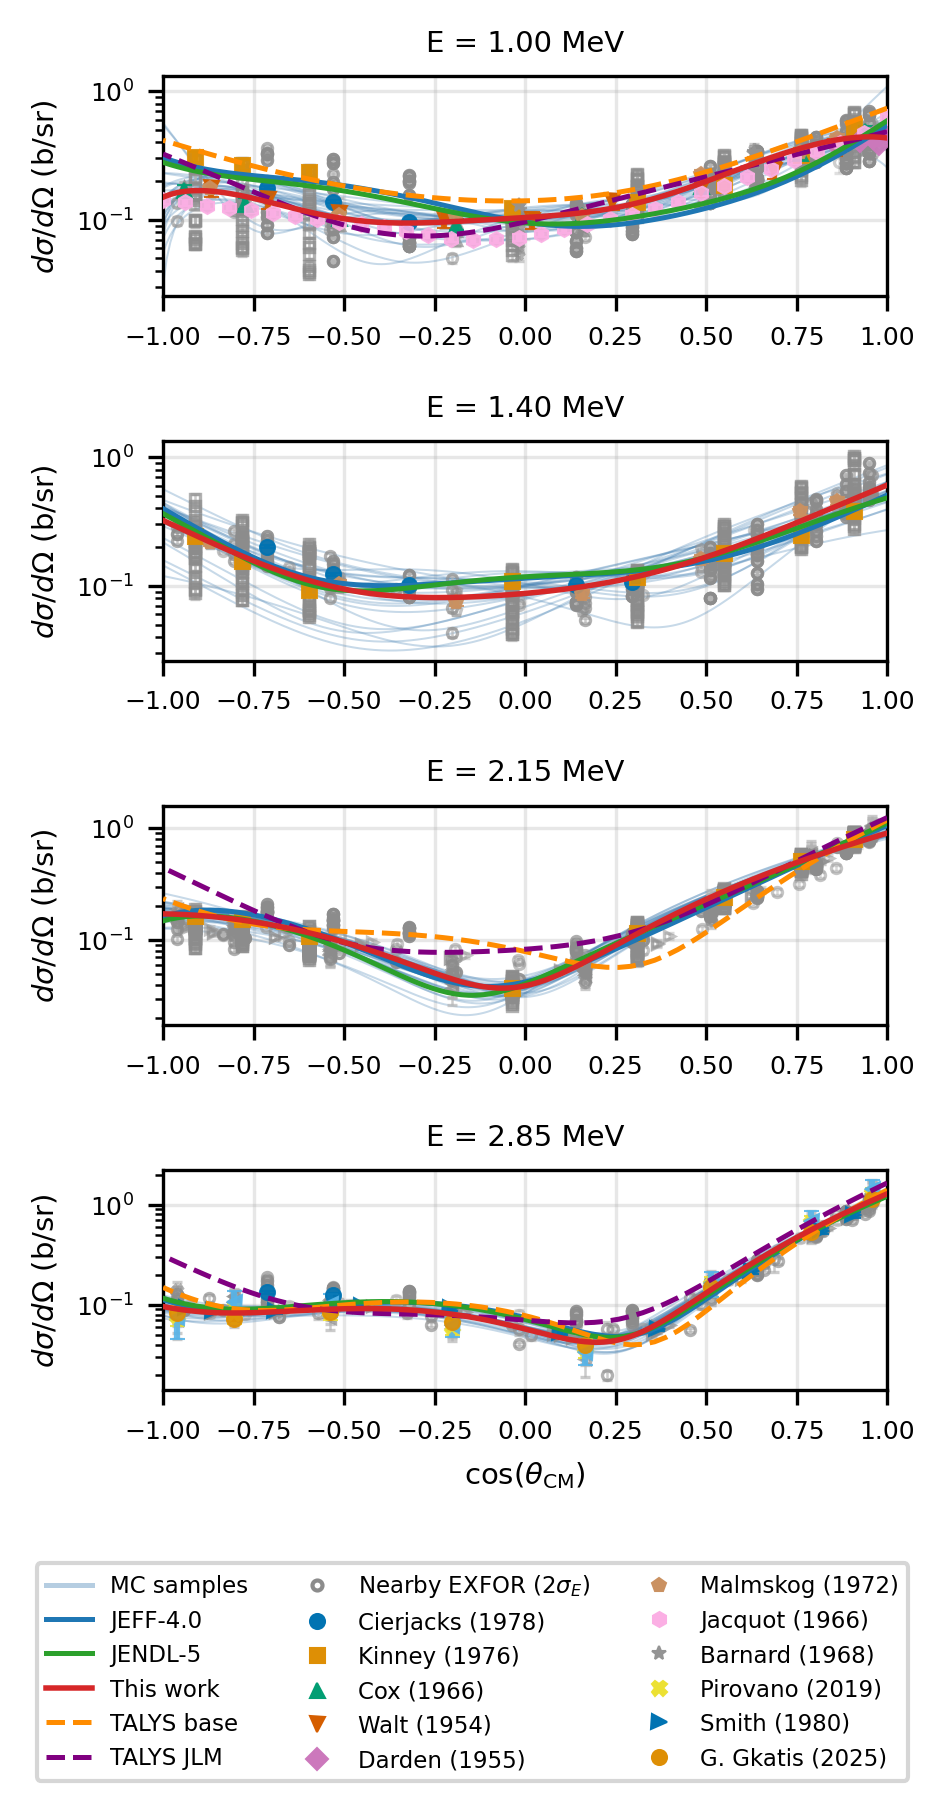


--- linear scale, 2col ---
Saved: /share_snc/snc/JuanMonleon/DA_Figures/samples/samples_multipanel_1.00_1.40_2.15_2.85_lin_2col.png


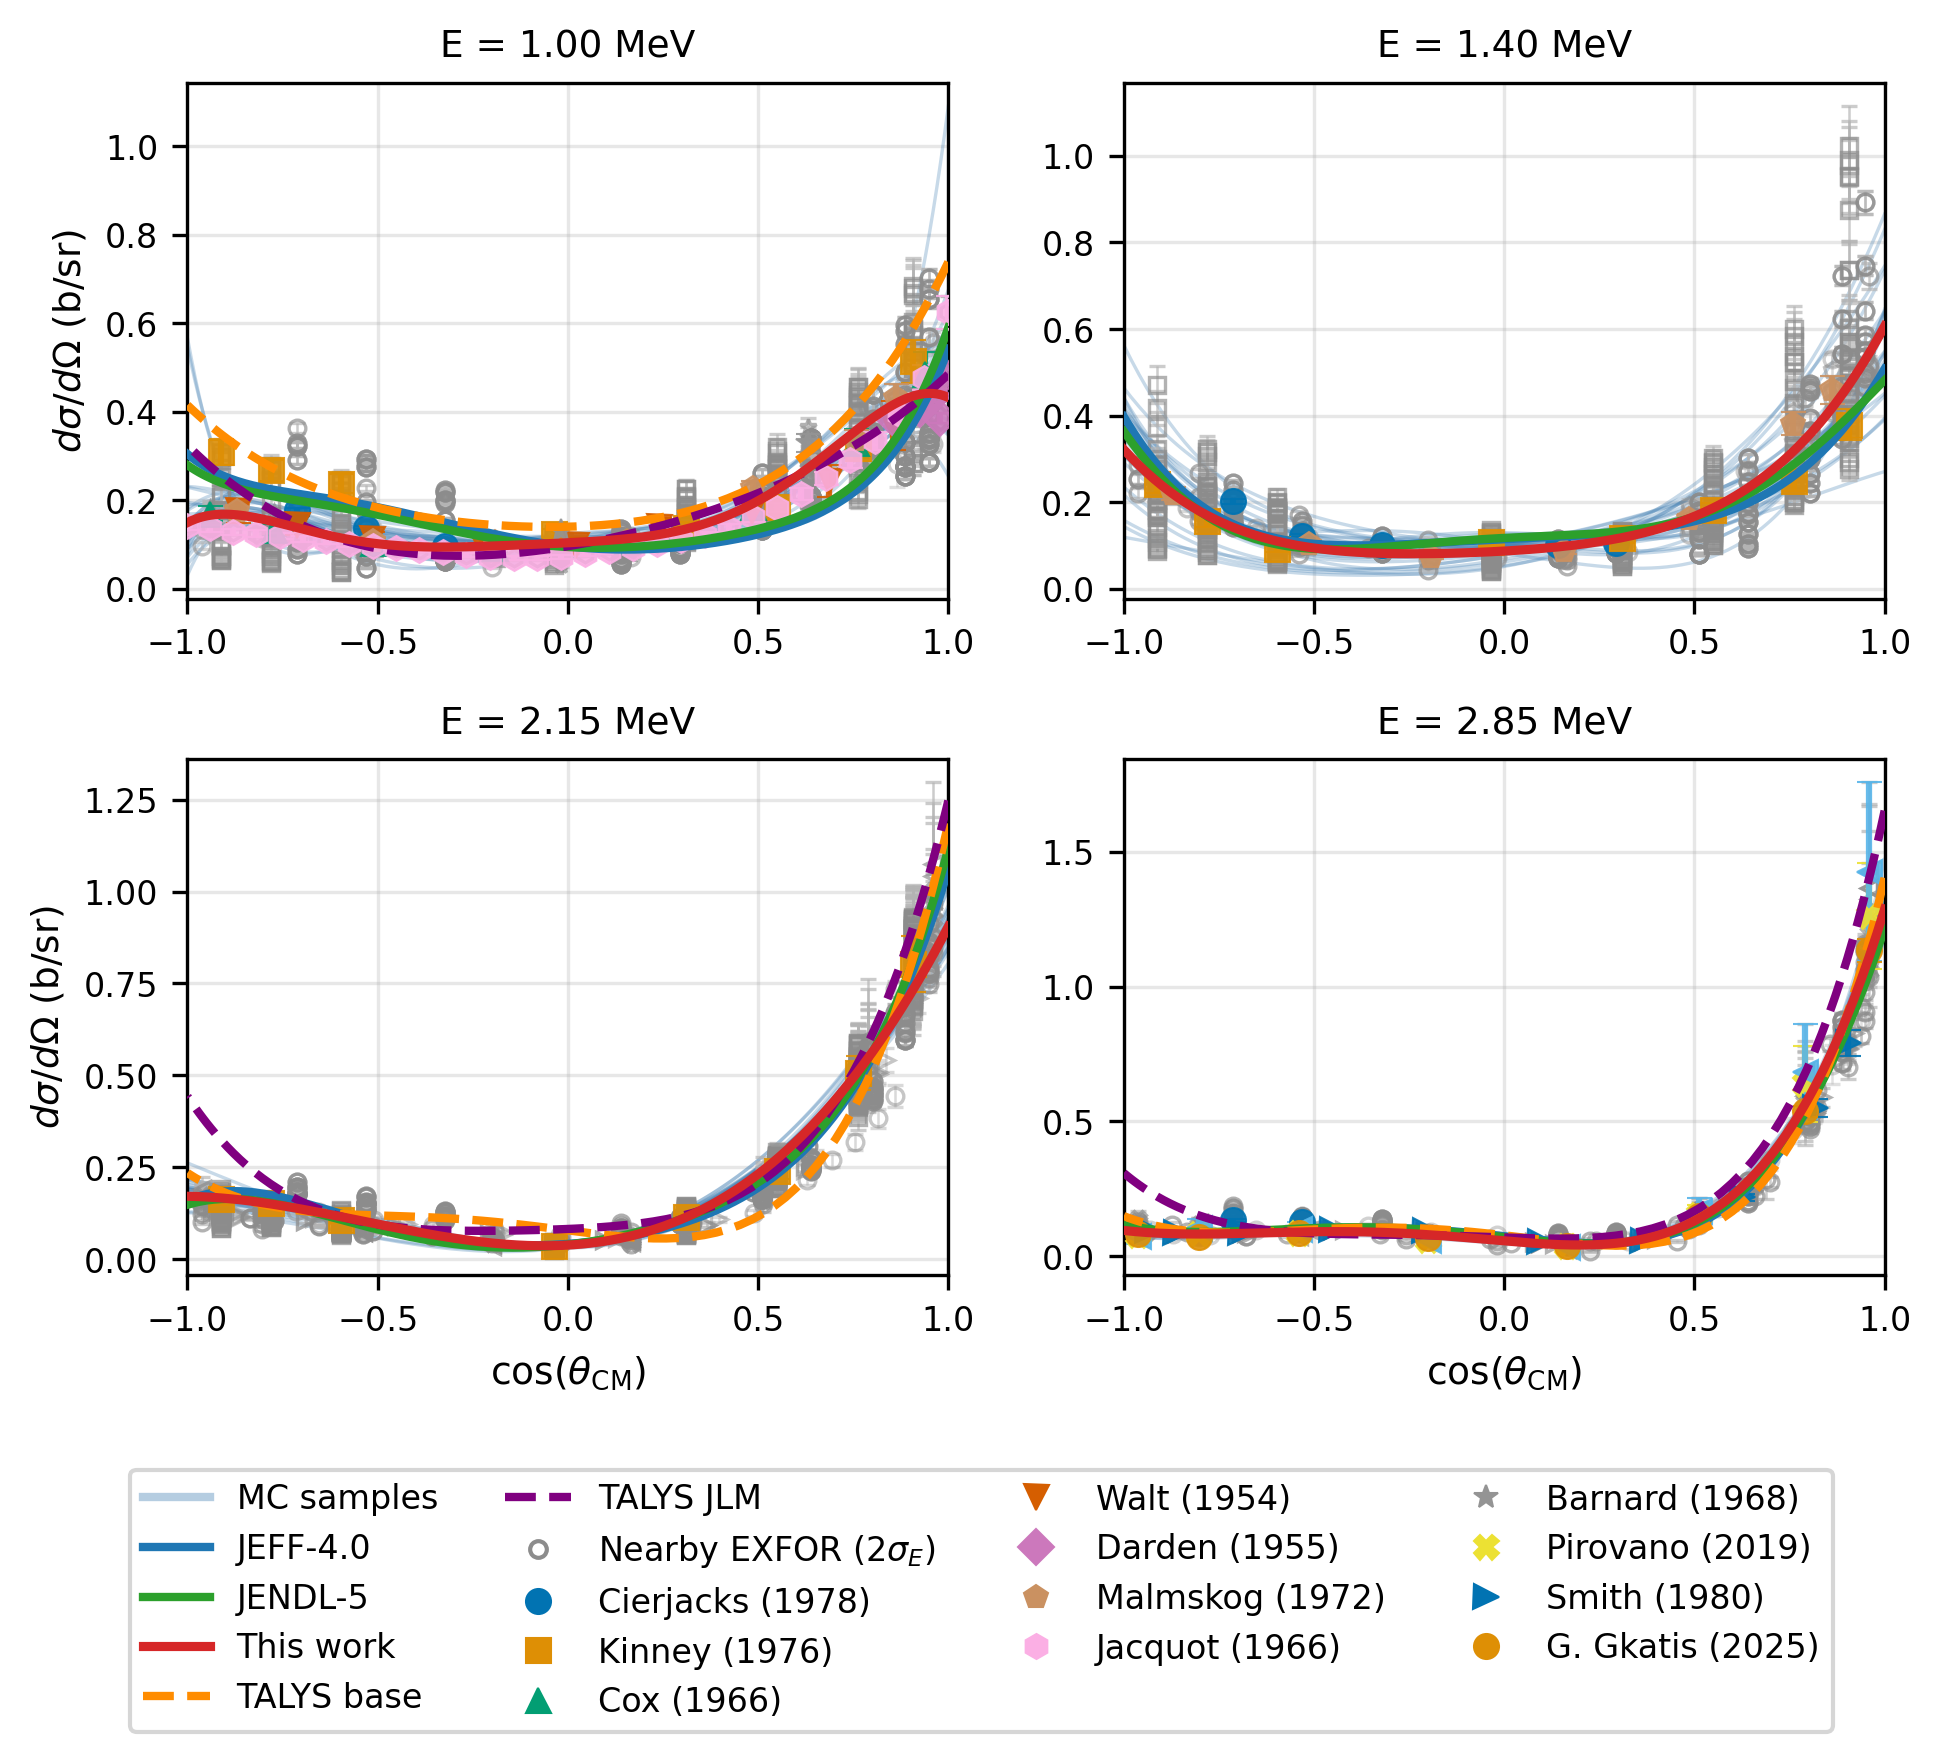


--- linear scale, 1col ---
Saved: /share_snc/snc/JuanMonleon/DA_Figures/samples/samples_multipanel_1.00_1.40_2.15_2.85_lin_1col.png


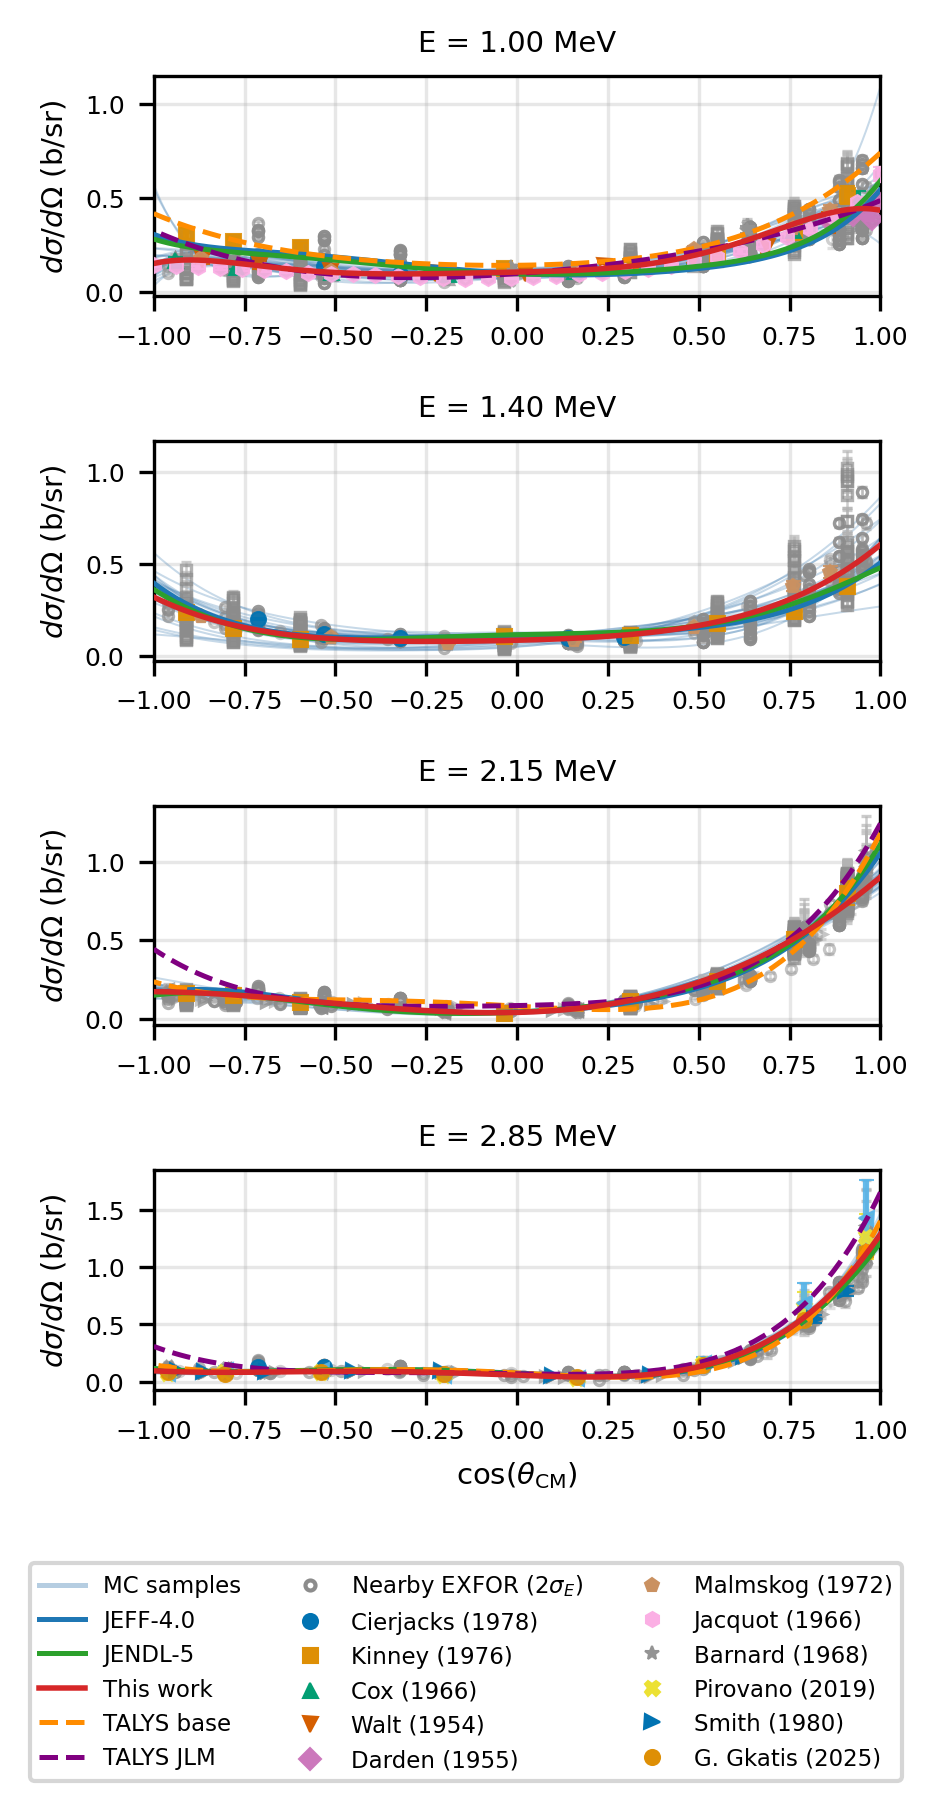

In [26]:
# Generate all figure variants
for yscale in ['log', 'linear']:
    for col_mode, figsize, fontsizes, lw_s, ms_s in [
        ('2col', FIGSIZE_2COL, FONTSIZES_2COL, 1.0, 1.0),
        ('1col', FIGSIZE_1COL, FONTSIZES_1COL, 0.6, 0.6),
    ]:
        scale_tag = 'log' if yscale == 'log' else 'lin'
        energies_tag = '_'.join(f'{e:.2f}' for e in TARGET_ENERGIES_MEV)

        save_path = None
        if SAVE_FIGURES:
            save_path = (f'{FIGURES_DIR}/samples_multipanel_{energies_tag}_'
                         f'{scale_tag}_{col_mode}.{FIGURE_FORMAT}')

        print(f"\n--- {yscale} scale, {col_mode} ---")
        fig = create_multipanel_figure(
            energy_results, TARGET_ENERGIES_MEV,
            global_exp_visual_map, global_exp_label_map,
            yscale=yscale, figsize=figsize, fontsizes=fontsizes,
            linewidth_scale=lw_s, markersize_scale=ms_s,
            save_path=save_path, dpi=FIGURE_DPI,
        )
        plt.show()

## 12. Optional: Diagnostics and Single-Panel Plots

In [27]:
# Optional diagnostic plots: per-energy Legendre fit verification
if SHOW_DIAGNOSTICS:
    from numpy.polynomial.legendre import legval

    for e_mev in TARGET_ENERGIES_MEV:
        result = energy_results[e_mev]
        fig, ax = plt.subplots(figsize=(8, 5))

        # Plot fit EXFOR data (colored)
        if not result.exfor_df.empty and 'experiment_id' in result.exfor_df.columns:
            for eid in result.exfor_df['experiment_id'].unique():
                mask = result.exfor_df['experiment_id'] == eid
                df_exp = result.exfor_df[mask]
                color, marker = global_exp_visual_map.get(eid, ('black', 'o'))
                label = global_exp_label_map.get(eid, eid)
                ax.errorbar(df_exp['mu'], df_exp['value'], yerr=df_exp['unc'],
                           fmt=marker, color=color, label=label,
                           capsize=3, markersize=8, alpha=0.9)

        # Plot Legendre fit
        mu_fit = np.linspace(-1, 1, 200)

        # Reconstruct fit coefficients from fit_info
        coef_df_diag, _ = sample_legendre_coefficients(
            df=result.exfor_df, value_col="value", unc_col="unc", mu_col="mu",
            degree=result.fit_degree, ridge_lambda=1e-6, n_samples=1,
            rescale_unc_by_chi2=True, external_weights=result.kernel_weights,
        )
        fit_coeffs = [coef_df_diag[f'c{i}'].values[0] for i in range(result.fit_degree + 1)]
        y_fit = legval(mu_fit, fit_coeffs)

        ax.plot(mu_fit, y_fit, 'r-', linewidth=2.5,
                label=f'Legendre fit (L={result.fit_degree})')
        ax.axhline(result.c0_exfor, color='orange', linestyle='--', linewidth=1.5,
                   alpha=0.7, label=f'c0 = {result.c0_exfor:.4f}')

        ax.set_xlabel(r'$\cos(\theta_{CM})$', fontsize=12)
        ax.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)', fontsize=12)
        ax.set_title(f'EXFOR Fit Diagnostic @ E = {e_mev:.2f} MeV | '
                     f'chi2_red = {result.fit_info["chi2_red"]:.2f}', fontsize=11)
        ax.set_xlim(-1, 1)
        ax.legend(loc='best', fontsize=8)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("Diagnostics disabled (set SHOW_DIAGNOSTICS = True to enable)")

Diagnostics disabled (set SHOW_DIAGNOSTICS = True to enable)


In [28]:
# Optional single-panel plots (backward compatibility)
if ALSO_GENERATE_SINGLE_PANELS:
    for e_mev in TARGET_ENERGIES_MEV:
        result = energy_results[e_mev]
        for yscale in ['log', 'linear']:
            fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
            hl = plot_ad_comparison(
                ax, result, global_exp_visual_map, global_exp_label_map,
                yscale=yscale, fontsizes=FONTSIZES_2COL,
            )
            # Per-subplot legend for single panels
            handles = [h for h, l in hl]
            labels = [l for h, l in hl]
            # Deduplicate
            seen = {}
            for h, l in zip(handles, labels):
                if l not in seen:
                    seen[l] = h
            ax.legend(list(seen.values()), list(seen.keys()), loc='best', fontsize=10)
            ax.set_xlabel(r'$\cos(\theta_{\rm CM})$', fontsize=12)
            ax.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)', fontsize=12)
            plt.tight_layout()

            if SAVE_FIGURES:
                scale_tag = 'log' if yscale == 'log' else 'lin'
                fig.savefig(f'{FIGURES_DIR}/samples_{e_mev:.2f}MeV_{scale_tag}.{FIGURE_FORMAT}',
                           dpi=FIGURE_DPI, bbox_inches='tight')
            plt.show()
else:
    print("Single-panel plots disabled (set ALSO_GENERATE_SINGLE_PANELS = True to enable)")

Single-panel plots disabled (set ALSO_GENERATE_SINGLE_PANELS = True to enable)


## 13. Summary Statistics

In [29]:
print("=" * 60)
print("SUMMARY")
print("=" * 60)

for e_mev in TARGET_ENERGIES_MEV:
    result = energy_results[e_mev]
    n_samples = len(result.sample_dsigma_array) if result.sample_dsigma_array is not None else 0

    print(f"\nE = {e_mev:.2f} MeV (grid: {result.closest_energy_mev:.4f} MeV):")
    print(f"  c0 = {result.c0_exfor:.6f} b/sr -> sigma_total = {4 * np.pi * result.c0_exfor:.4f} b")
    print(f"  chi2_red = {result.fit_info['chi2_red']:.2f}, Birge scale = {result.fit_info['scale_factor']:.3f}")
    print(f"  EXFOR fit points: {len(result.exfor_df)}")
    print(f"  Extended EXFOR points: {len(result.ext_df)}")
    print(f"  MC samples: {n_samples}")
    print(f"  Legendre order: L = {result.fit_degree}")

    # Normalization check
    avg_jeff = np.mean(result.dsigma_jeff)
    print(f"  JEFF avg dsigma = {avg_jeff:.6f} (ratio to c0: {avg_jeff/result.c0_exfor:.4f})")

print("\n" + "=" * 60)
print(f"Total unique experiments in visual map: {len(global_exp_visual_map)}")
print("=" * 60)

SUMMARY

E = 1.00 MeV (grid: 1.0000 MeV):
  c0 = 0.178627 b/sr -> sigma_total = 2.2447 b
  chi2_red = 12.75, Birge scale = 3.570
  EXFOR fit points: 75
  Extended EXFOR points: 735
  MC samples: 25
  Legendre order: L = 6
  JEFF avg dsigma = 0.179863 (ratio to c0: 1.0069)

E = 1.40 MeV (grid: 1.4000 MeV):
  c0 = 0.176847 b/sr -> sigma_total = 2.2223 b
  chi2_red = 8.72, Birge scale = 2.953
  EXFOR fit points: 20
  Extended EXFOR points: 644
  MC samples: 25
  Legendre order: L = 6
  JEFF avg dsigma = 0.178239 (ratio to c0: 1.0079)

E = 2.15 MeV (grid: 2.1500 MeV):
  c0 = 0.205443 b/sr -> sigma_total = 2.5817 b
  chi2_red = 0.11, Birge scale = 1.000
  EXFOR fit points: 8
  Extended EXFOR points: 930
  MC samples: 25
  Legendre order: L = 6
  JEFF avg dsigma = 0.207474 (ratio to c0: 1.0099)

E = 2.85 MeV (grid: 2.8500 MeV):
  c0 = 0.194509 b/sr -> sigma_total = 2.4443 b
  chi2_red = 10.24, Birge scale = 3.200
  EXFOR fit points: 36
  Extended EXFOR points: 387
  MC samples: 25
  Legendre